# Ejercicio 3 — Detección de fraudes mediante Programación Genética

Se generan datos artificiales con **monto, hora del día, distancia a la residencia, ingreso mensual y fraude (sí/no)**. Luego se utiliza Programación Genética (PG) con **DEAP** para encontrar una regla de clasificación.

## 1. Instalar e importar librerías

In [72]:
!pip -q install deap


In [73]:
import random
import operator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deap import base, creator, tools, gp, algorithms
from functools import partial


## 2. Generar los datos

Las variables solicitadas son:

$$\text{monto},\quad \text{hora},\quad \text{distancia},\quad \text{ingreso mensual}$$

con salida:

$$\text{fraude}\in\{0,1\}$$

Para hacer los datos artificiales más razonables, se considera sospechosa una transacción si presenta un monto alto respecto al ingreso, ocurre de madrugada o se realiza lejos de la residencia. Se marca fraude cuando se cumplen al menos dos condiciones. Estas reglas **solo generan los datos**; la PG deberá descubrir una regla a partir de ellos.

In [74]:
N = 300
datos = []

for _ in range(N):
    monto = random.uniform(10_000, 5_000_000)
    hora = random.randint(0, 23)
    distancia = random.uniform(0, 100)
    ingreso = random.uniform(1_000_000, 10_000_000)

    c1 = monto > 0.40 * ingreso
    c2 = hora <= 4
    c3 = distancia > 60
    fraude = int(c1 + c2 + c3 >= 2)

    datos.append([monto, hora, distancia, ingreso, fraude])

df = pd.DataFrame(datos, columns=['Monto','Hora','Distancia','Ingreso','Fraude'])
df.head(10)


,Monto,Hora,Distancia,Ingreso,Fraude
0,2.256758e+06,3,89.073557,6.672523e+06,1
1,1.462468e+06,3,29.591909,3.560802e+06,1
2,1.375697e+06,22,15.470404,5.333160e+06,0
3,9.522692e+05,4,38.261769,9.167150e+06,0
4,2.179406e+06,8,76.338943,5.603081e+06,0
5,3.830823e+06,8,81.229910,8.124156e+06,1
6,4.399609e+06,15,73.918393,1.171586e+06,1
7,3.171877e+06,14,17.238838,9.317027e+06,0
8,4.354911e+06,16,22.438639,3.509721e+06,0
9,4.164006e+05,12,94.164871,7.119227e+06,0


In [75]:
print('Transacciones:', len(df))
print(df['Fraude'].value_counts().rename(index={0:'No fraude', 1:'Fraude'}))


Transacciones: 300
Fraude
No fraude    181
Fraude       119
Name: count, dtype: int64


## 3. Elementos de la Programación Genética

### Terminales

$$T=\{\text{Monto},\text{Hora},\text{Distancia},\text{Ingreso}\}$$

### Funciones

Se utilizarán operaciones sencillas:

$$F=\{+,-,>,<,\mathrm{AND},\mathrm{OR}\}$$

Cada individuo será un **árbol** que combine estas funciones y terminales.

In [76]:
def AND(x, y):
    return bool(x) and bool(y)

def OR(x, y):
    return bool(x) or bool(y)

def mayor(x, y):
    return x > y

def menor(x, y):
    return x < y


pset = gp.PrimitiveSetTyped(
    "MAIN",
    [float, float, float, float],
    bool
)


# Operaciones matemáticas
pset.addPrimitive(operator.add, [float, float], float)
pset.addPrimitive(operator.sub, [float, float], float)


# Comparaciones
pset.addPrimitive(mayor, [float, float], bool)
pset.addPrimitive(menor, [float, float], bool)


# Operaciones lógicas
pset.addPrimitive(AND, [bool, bool], bool)
pset.addPrimitive(OR, [bool, bool], bool)


# Terminales booleanos auxiliares
pset.addTerminal(True, bool)
pset.addTerminal(False, bool)


# Constantes numéricas aleatorias
pset.addEphemeralConstant(
    "constante",
    partial(
        random.uniform,
        -5_000_000,
        5_000_000
    ),
    float
)


# Nombres de las variables de entrada
pset.renameArguments(
    ARG0="Monto",
    ARG1="Hora",
    ARG2="Distancia",
    ARG3="Ingreso"
)


## 4. Función de aptitud

La aptitud corresponde a la proporción de transacciones correctamente clasificadas:

$$\text{Aptitud}=\frac{\text{clasificaciones correctas}}{\text{número total de transacciones}}$$

Por tanto:

$$0\leq\text{Aptitud}\leq1$$

Una aptitud de **1** representa una clasificación perfecta.

In [77]:
if not hasattr(creator, 'FitnessFraude'):
    creator.create('FitnessFraude', base.Fitness, weights=(1.0,))
if not hasattr(creator, 'IndividuoFraude'):
    creator.create('IndividuoFraude', gp.PrimitiveTree, fitness=creator.FitnessFraude)

toolbox = base.Toolbox()
toolbox.register('expr', gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register('individual', tools.initIterate, creator.IndividuoFraude, toolbox.expr)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)
toolbox.register('compile', gp.compile, pset=pset)


## 5. Evaluar los individuos

Cada árbol recibe las cuatro variables y devuelve `True` (posible fraude) o `False` (transacción normal).

In [78]:
def evaluar(individuo):

    programa = toolbox.compile(expr=individuo)

    TP = TN = FP = FN = 0

    for fila in df.itertuples(index=False):

        pred = int(bool(programa(
            float(fila.Monto),
            float(fila.Hora),
            float(fila.Distancia),
            float(fila.Ingreso)
        )))

        real = int(fila.Fraude)

        if real == 1 and pred == 1:
            TP += 1
        elif real == 0 and pred == 0:
            TN += 1
        elif real == 0 and pred == 1:
            FP += 1
        elif real == 1 and pred == 0:
            FN += 1

    sensibilidad = TP / (TP + FN) if (TP + FN) > 0 else 0
    especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0

    aptitud = (sensibilidad + especificidad) / 2

    return (aptitud,)


toolbox.register("evaluate", evaluar)

toolbox.register(
    "select",
    tools.selTournament,
    tournsize=3
)

toolbox.register(
    "mate",
    gp.cxOnePoint
)

toolbox.register(
    "expr_mut",
    gp.genFull,
    min_=0,
    max_=2
)

toolbox.register(
    "mutate",
    gp.mutUniform,
    expr=toolbox.expr_mut,
    pset=pset
)

toolbox.decorate(
    "mate",
    gp.staticLimit(
        key=operator.attrgetter("height"),
        max_value=8
    )
)

toolbox.decorate(
    "mutate",
    gp.staticLimit(
        key=operator.attrgetter("height"),
        max_value=8
    )
)


## 6. Ejecutar la PG

Se utilizan **100 individuos**, probabilidad de cruce **0.7**, mutación **0.01** y **50 generaciones**. El mejor individuo se conserva en un `HallOfFame`.

In [79]:
poblacion = toolbox.population(n=100)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values[0])
stats.register('max', np.max)
stats.register('avg', np.mean)

poblacion, log = algorithms.eaSimple(
    poblacion, toolbox,
    cxpb=0.7, mutpb=0.01, ngen=50,
    stats=stats, halloffame=hof, verbose=True
)


gen	nevals	max     	avg     
0  	100   	0.694159	0.508527
1  	64    	0.694159	0.526778
2  	70    	0.694159	0.545555
3  	73    	0.73866 	0.572805
4  	73    	0.749362	0.566966
5  	79    	0.730767	0.581766
6  	80    	0.750569	0.589162
7  	70    	0.750569	0.607734
8  	64    	0.73866 	0.617075
9  	77    	0.752356	0.62167 
10 	77    	0.752356	0.634432
11 	66    	0.752356	0.660172
12 	73    	0.755003	0.661605
13 	72    	0.755003	0.668912
14 	75    	0.755003	0.677893
15 	68    	0.755003	0.681805
16 	76    	0.755003	0.663145
17 	56    	0.755003	0.692324
18 	79    	0.755003	0.665154
19 	70    	0.755003	0.656803
20 	75    	0.755003	0.666088
21 	74    	0.755003	0.687904
22 	78    	0.755119	0.686754
23 	82    	0.755119	0.666901
24 	75    	0.755119	0.674949
25 	68    	0.755119	0.682971
26 	70    	0.755119	0.690286
27 	76    	0.755119	0.682376
28 	75    	0.755119	0.681856
29 	68    	0.755119	0.692797
30 	71    	0.755119	0.70364 
31 	74    	0.755119	0.709202
32 	69    	0.755119	0.707372
33 	66    	0.7

## 7. Mejor modelo encontrado

In [80]:
mejor = hof[0]
print('Mejor expresión encontrada:')
print(mejor)
print(f'\nAptitud: {mejor.fitness.values[0]*100:.2f}%')


Mejor expresión encontrada:
mayor(sub(add(Monto, 701336.3405383974), Distancia), add(add(sub(Ingreso, Hora), sub(add(sub(487453.42522893194, add(Monto, Distancia)), add(Hora, Distancia)), Distancia)), sub(sub(sub(add(sub(487453.42522893194, Distancia), add(sub(487453.42522893194, Distancia), Distancia)), Distancia), Distancia), Monto)))

Aptitud: 75.51%


## 8. Verificar las predicciones

In [81]:
modelo = toolbox.compile(expr=mejor)
df['Prediccion_PG'] = [int(bool(modelo(float(f.Monto),float(f.Hora),float(f.Distancia),float(f.Ingreso)))) for f in df.itertuples(index=False)]
df.head(20)


,Monto,Hora,Distancia,Ingreso,Fraude,Prediccion_PG
0,2.256758e+06,3,89.073557,6.672523e+06,1,0
1,1.462468e+06,3,29.591909,3.560802e+06,1,1
2,1.375697e+06,22,15.470404,5.333160e+06,0,0
3,9.522692e+05,4,38.261769,9.167150e+06,0,0
4,2.179406e+06,8,76.338943,5.603081e+06,0,1
5,3.830823e+06,8,81.229910,8.124156e+06,1,1
6,4.399609e+06,15,73.918393,1.171586e+06,1,1
7,3.171877e+06,14,17.238838,9.317027e+06,0,0
8,4.354911e+06,16,22.438639,3.509721e+06,0,1
9,4.164006e+05,12,94.164871,7.119227e+06,0,0


## 9. Matriz de confusión

In [82]:
pd.crosstab(df['Fraude'], df['Prediccion_PG'], rownames=['Real'], colnames=['Predicción'])


Predicción,0,1
Real,,
0,103,78
1,7,112


## 10. Evolución de la aptitud

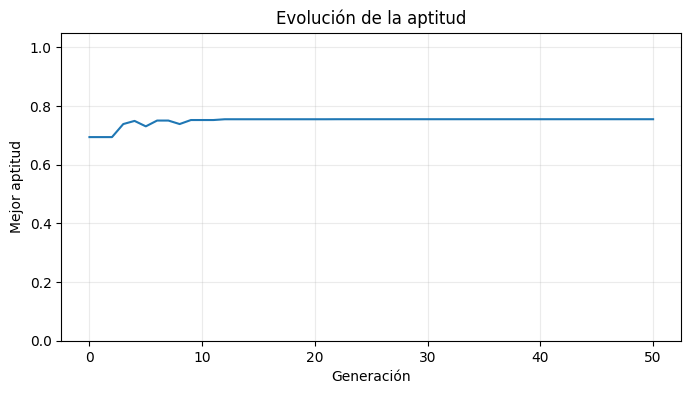

In [83]:
plt.figure(figsize=(8,4))
plt.plot(log.select('gen'), log.select('max'))
plt.xlabel('Generación')
plt.ylabel('Mejor aptitud')
plt.title('Evolución de la aptitud')
plt.ylim(0,1.05)
plt.grid(alpha=0.25)
plt.show()


## 11. Guardar el archivo generado

In [84]:
df.to_csv('datos_fraude_pg.csv', index=False)
print('Archivo guardado: datos_fraude_pg.csv')


Archivo guardado: datos_fraude_pg.csv
